# Credit-G Dataset EDA

In [3]:
import pandas as pd
from scipy.io import arff
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
data, meta = arff.loadarff('dataset_31_credit-g.arff')

In [ ]:
# creating the dataset only for plotting purposes

df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.decode('utf-8')
        except:
            pass

In [ ]:
# creating the dataset with one-hot encoding

df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.decode('utf-8')
        except Exception:
            pass

categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

target_col = None
for candidate in ['class', 'target', 'label', 'y']:
    if candidate in df.columns:
        target_col = candidate
        break

ohe_cols = [c for c in categorical_cols if c != target_col]
df_ohe = pd.get_dummies(df, columns=ohe_cols, drop_first=False, dtype=int)

if target_col is not None:
    X_ohe = df_ohe.drop(columns=[target_col])
    y = df_ohe[target_col]
else:
    X_ohe = df_ohe

print(f"Raw df shape: {df.shape}")
print(f"One-hot df_ohe shape: {df_ohe.shape}")
print(f"One-hot features shape (X_ohe): {X_ohe.shape}")
if target_col is not None:
    print(f"Target column: {target_col} (dtype={y.dtype})")

Raw df shape: (1000, 21)
One-hot df_ohe shape: (1000, 62)
One-hot features shape (X_ohe): (1000, 61)
Target column: class (dtype=object)


In [10]:
df_ohe.head

<bound method NDFrame.head of      duration  credit_amount  installment_commitment  residence_since   age  \
0         6.0         1169.0                     4.0              4.0  67.0   
1        48.0         5951.0                     2.0              2.0  22.0   
2        12.0         2096.0                     2.0              3.0  49.0   
3        42.0         7882.0                     2.0              4.0  45.0   
4        24.0         4870.0                     3.0              4.0  53.0   
..        ...            ...                     ...              ...   ...   
995      12.0         1736.0                     3.0              4.0  31.0   
996      30.0         3857.0                     4.0              4.0  40.0   
997      12.0          804.0                     4.0              4.0  38.0   
998      45.0         1845.0                     4.0              4.0  23.0   
999      45.0         4576.0                     3.0              4.0  27.0   

     existing_credits

Column 'installment_commitment' has 4 unique values - treating as categorical
Column 'residence_since' has 4 unique values - treating as categorical
Column 'existing_credits' has 4 unique values - treating as categorical
Column 'num_dependents' has 2 unique values - treating as categorical


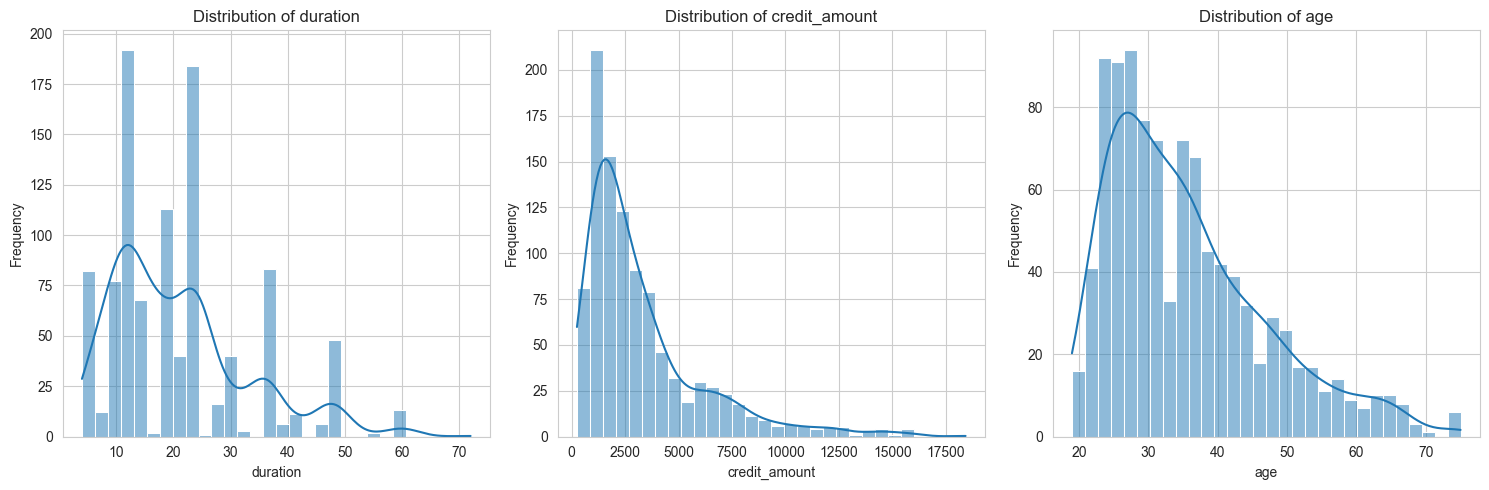

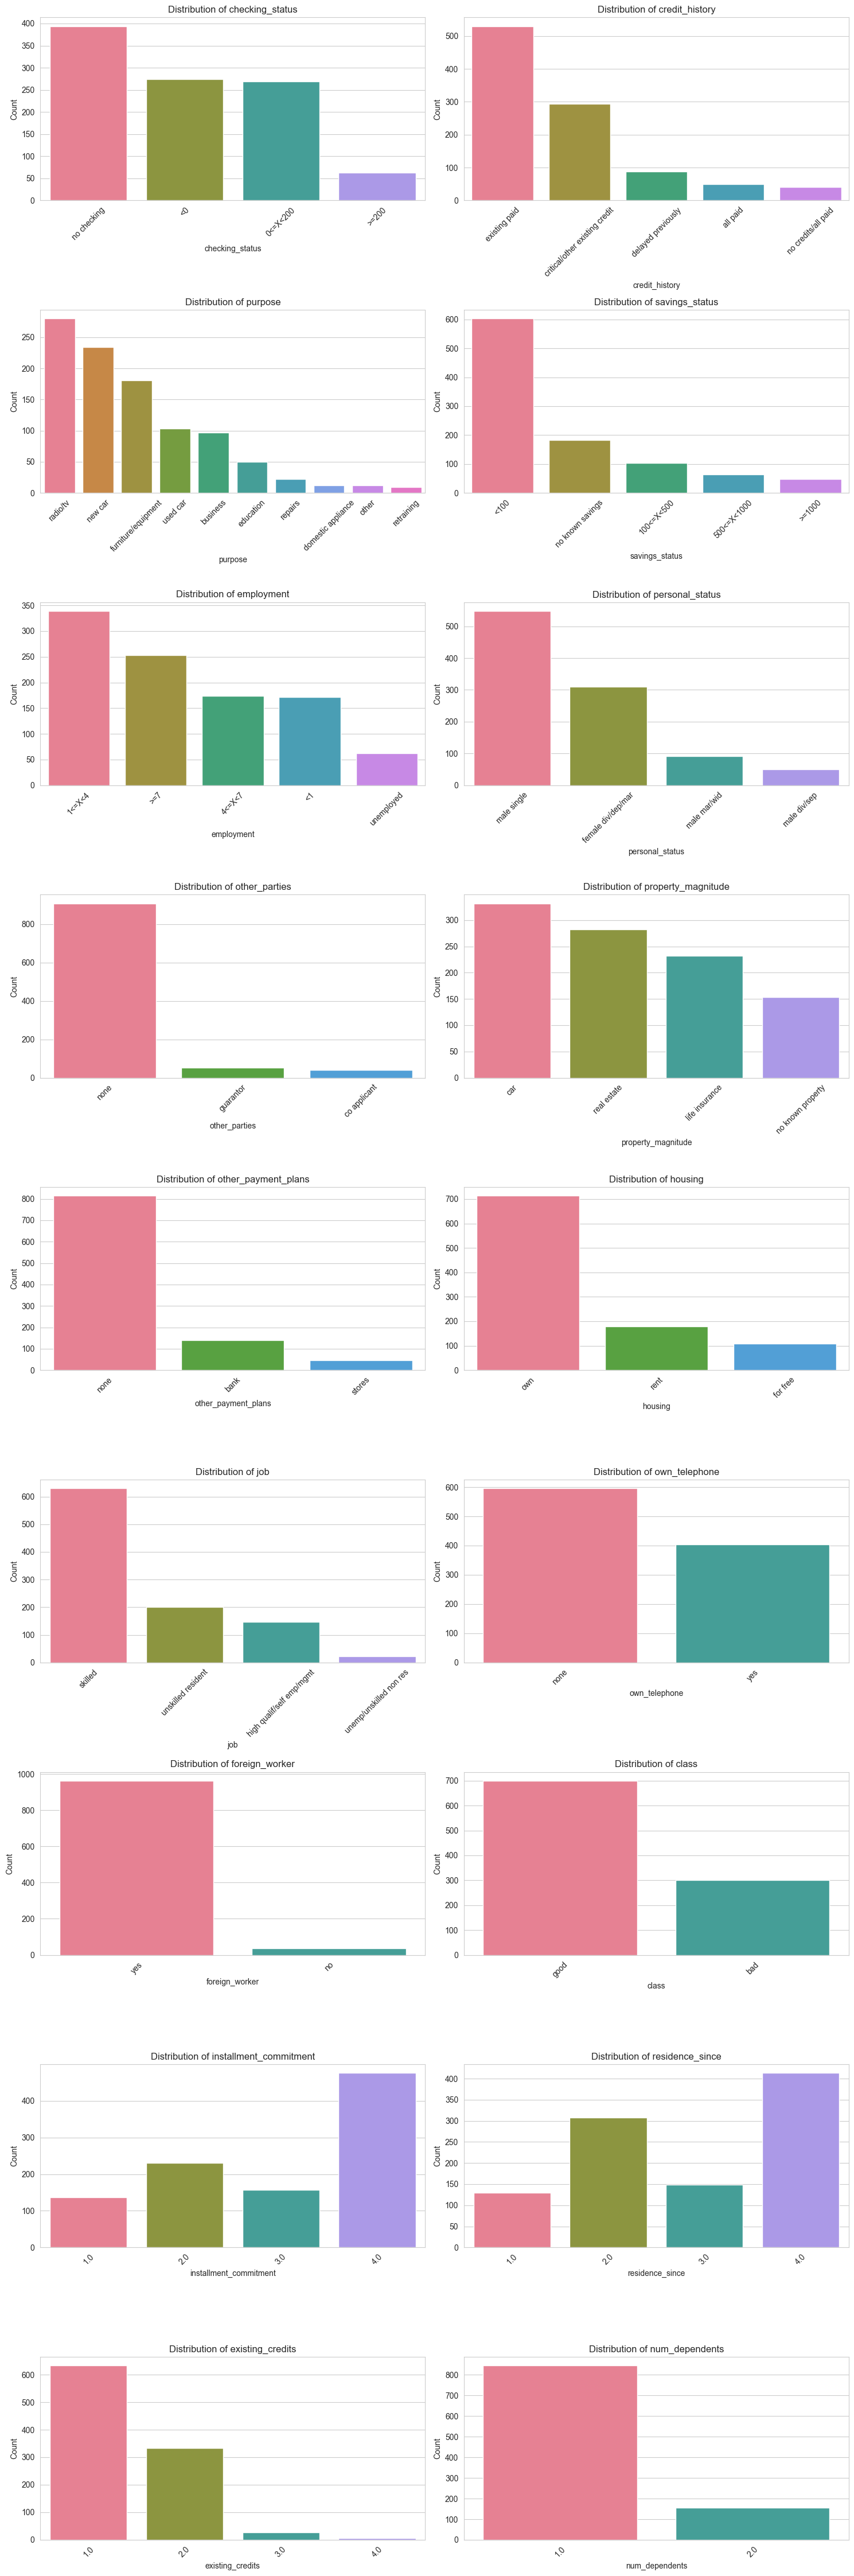

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

truly_numeric_cols = []
for col in numeric_cols:
    if df[col].nunique() < 5:
        categorical_cols.append(col)
        print(f"Column '{col}' has {df[col].nunique()} unique values - treating as categorical")
    else:
        truly_numeric_cols.append(col)

numeric_cols = truly_numeric_cols

if numeric_cols:
    n_numeric = len(numeric_cols)
    n_cols = 3
    n_rows = (n_numeric + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_numeric > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        sns.histplot(df[col], kde=True, ax=axes[idx], bins=30)
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
    
    for idx in range(n_numeric, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

if categorical_cols:
    n_categorical = len(categorical_cols)
    n_cols = 2
    n_rows = (n_categorical + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_categorical > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts()
        colors = sns.color_palette("husl", len(value_counts))
        sns.barplot(x=value_counts.index, y=value_counts.values, hue=value_counts.index, 
                    ax=axes[idx], palette=colors, legend=False)
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)
    
    for idx in range(n_categorical, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()